In [13]:
# notebooks/02_flood_exploration.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import json
from pathlib import Path
import sys
import os
import logging

warnings.filterwarnings('ignore')

try:
    project_root = Path(__file__).resolve().parents[1]
except NameError:
    project_root = Path.cwd()
    if project_root.name == 'notebooks':
        project_root = project_root.parent

# validate critical files/directories exist
config_file = project_root / 'config' / 'config.yaml'

# add project root to Python path BEFORE importing project modules
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.collectors.usgs_flood import USGSFloodCollector
from src.utils.helpers import setup_logging, load_config, DataValidator

# create logs directory before setting up logging
log_dir = project_root / 'logs'
log_dir.mkdir(exist_ok=True)

# setup logging with absolute path
logger = setup_logging(str(log_dir / 'notebook_flood_exploration.log'))

# load config with absolute path
try:
    config = load_config(str(config_file))
    logger.info(f"Config loaded successfully from {config_file}")
except FileNotFoundError as e:
    logger.error(f"Config file not found: {e}")
    raise

2026-02-07 23:25:19,331 - src.utils.helpers - INFO - Config loaded successfully from c:\Users\woodn\OneDrive\Desktop\MAPOU_LAB_CAPSTONE\earthquake-flood-alert\config\config.yaml


In [14]:
# matplotlib/Seaborn setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# define data directories using project_root
data_dir = project_root / "data"
raw_dir = data_dir / "raw" / "floods"
processed_dir = data_dir / "processed"

# create directories if they don't exist
for d in [data_dir, raw_dir, processed_dir, log_dir]:
    d.mkdir(parents=True, exist_ok=True)

df['date'] = pd.to_datetime(df['date'])


2026-02-07 23:24:11,496 - src.utils.helpers - INFO - Loaded existing flood data from c:\Users\woodn\OneDrive\Desktop\MAPOU_LAB_CAPSTONE\earthquake-flood-alert\data\raw\floods\07374000_Mississippi_River_at_Baton_Rouge_LA_training.csv




FLOOD DATA EXPLORATION

Analyzing: Mississippi River at Baton Rouge, LA
Site ID: 07374000
Loaded 5,079 records from 07374000_Mississippi_River_at_Baton_Rouge_LA_training.csv
Date range: 2010-01-01 00:00:00+00:00 to 2024-01-01 00:00:00+00:00
Using discharge column: 00060_Mean


BASIC STATISTICS
Total records: 5,079
Date range: 2010-01-01 00:00:00+00:00 to 2024-01-01 00:00:00+00:00
Duration: 5,113 days

Discharge statistics (cubic feet/second)
count    5.079000e+03
mean     5.800126e+05
std      3.002734e+05
min      1.310000e+05
25%      3.270000e+05
50%      5.370000e+05
75%      7.765000e+05
max      1.430000e+06


DATA QUALITY CHECK
Missing values:
date                 0
site_no              0
00060_Mean           0
00060_Mean_cd        0
00065_Maximum       51
00065_Maximum_cd    51
00065_Minimum       51
00065_Minimum_cd    51
00065_Mean          47
00065_Mean_cd       47
site_name            0
site_id              0
dtype: int64
Duplicates: 0


FLOOD THRESHOLD ANALYSIS
50th perc

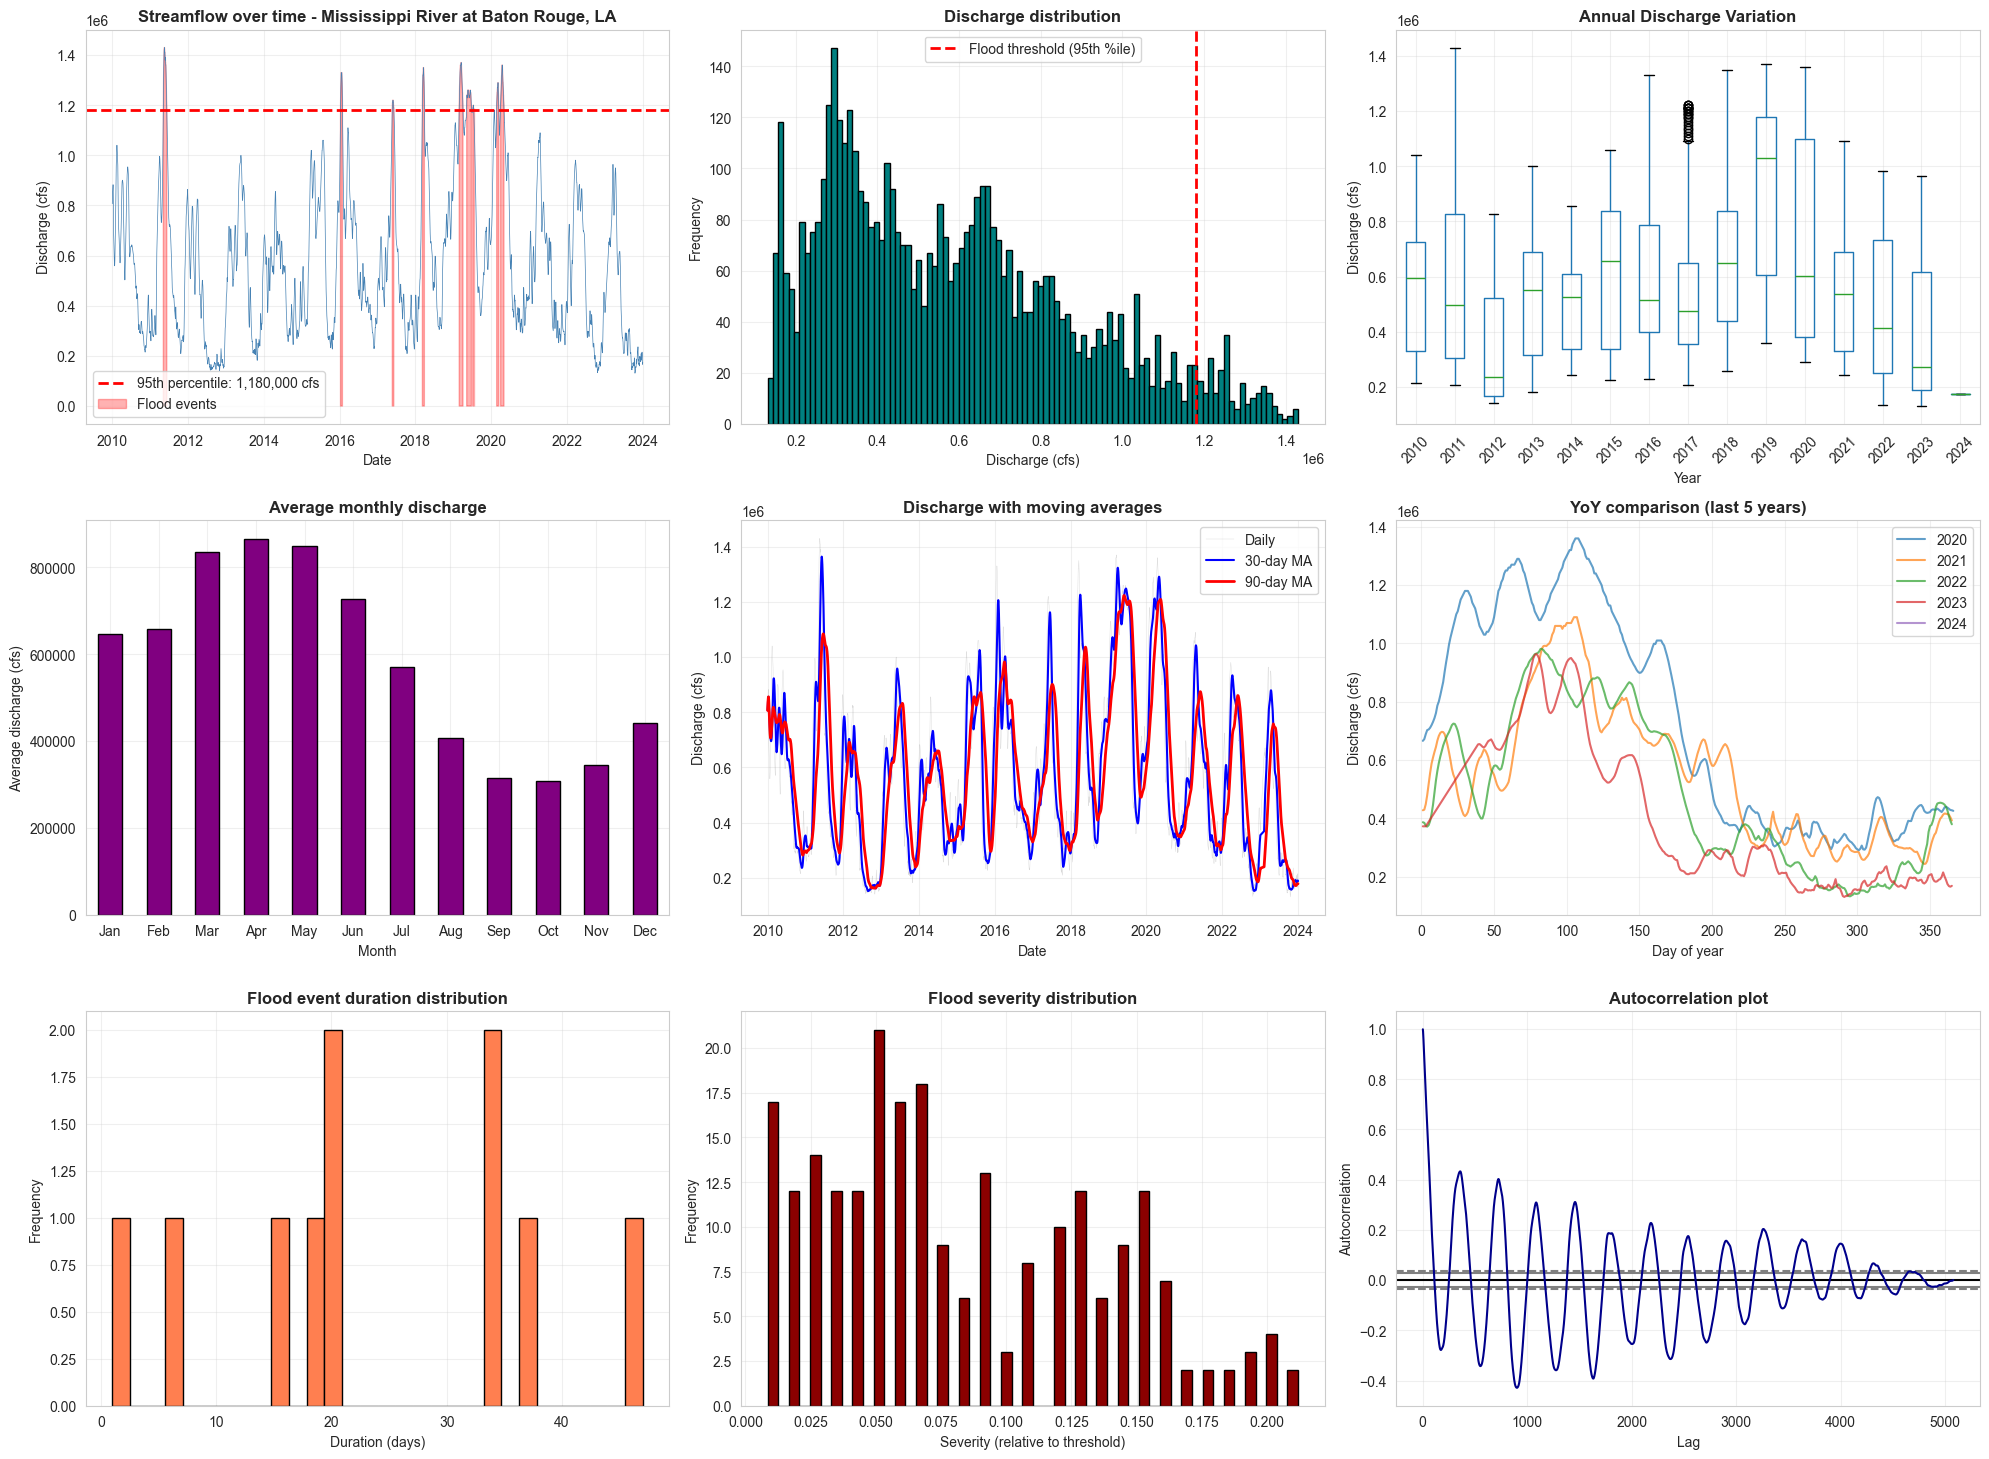

In [ ]:
def explore_flood_data():
    """Flood data exploration"""
    
    print("\n")
    print("FLOOD DATA EXPLORATION")
    
    monitoring_sites = config['flood']['monitoring_sites']
    
    # focus on one site for detailed analysis
    site_id = '07374000'  # Mississippi River at Baton Rouge
    site_name = monitoring_sites.get(site_id, "Unknown Site")
    
    print(f"\nAnalyzing: {site_name}")
    print(f"Site ID: {site_id}")
    
    # Load or fetch data
    try:
        # generate safe filenames
        safe_name = site_name.replace(' ', '_').replace(',', '').replace('/', '_')
        filename = f"{site_id}_{safe_name}_training.csv"
        filepath = raw_dir / filename
        
        df = pd.read_csv(filepath)
        logger.info(f"Loaded existing flood data from {filepath}")
        
        # parse date column
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            
            # drop rows with unparseable dates
            invalid_count = df['date'].isna().sum()
            if invalid_count > 0:
                logger.warning(f"Dropping {invalid_count:,} rows with invalid dates")
                df = df.dropna(subset=['date']).reset_index(drop=True)
        
        print(f"Loaded {len(df):,} records from {filepath.name}")
        print(f"Date range: {df['date'].min()} to {df['date'].max()}")
        
    except FileNotFoundError:
        print(f"Training data not found at {raw_dir / filename}. Running collector first...")
        
        collector = USGSFloodCollector(monitoring_sites)
        df = collector.fetch_daily_values(
            site_id,
            start_date=config['flood']['training']['start_date'],
            end_date=config['flood']['training']['end_date']
        )
        
        if df is None:
            print("Failed to fetch data from USGS API!")
            return None
        
        # parse date column
        if 'date' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['date']):
            df['date'] = pd.to_datetime(df['date'])
        
        # drop any remaining invalid dates
        invalid_count = df['date'].isna().sum()
        if invalid_count > 0:
            logger.warning(f"Dropping {invalid_count:,} rows with invalid dates before saving")
            df = df.dropna(subset=['date']).reset_index(drop=True)
        
        # save with safe filename
        safe_name = site_name.replace(' ', '_').replace(',', '').replace('/', '_')
        filename = f"{site_id}_{safe_name}_training.csv"
        collector.save_data(df, filename)
        print(f"Saved {len(df):,} records to {raw_dir / filename}")
    
    # find discharge column (parameter code 00060 = streamflow)
    discharge_cols = [col for col in df.columns if '00060' in col and 'Mean' in col]
    if not discharge_cols:
        # look for any column containing discharge values
        discharge_cols = [col for col in df.columns if 'discharge' in col.lower() or 'streamflow' in col.lower()]
    
    if not discharge_cols:
        print("Error: No discharge column found! Available columns:")
        for col in df.columns:
            print(f"  - {col}")
        logger.error("No discharge column found in flood data")
        return None
    
    discharge_col = discharge_cols[0]
    print(f"Using discharge column: {discharge_col}")
    
    # basic Statistics
    print("\n")
    print("BASIC STATISTICS")
    print(f"Total records: {len(df):,}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Duration: {(df['date'].max() - df['date'].min()).days:,} days")
    
    print(f"\nDischarge statistics (cubic feet/second)")
    print(df[discharge_col].describe().to_string())
    
    # data quality check
    print("\n")
    print("DATA QUALITY CHECK")
    print(f"Missing values:\n{df.isnull().sum()}")
    print(f"Duplicates: {df.duplicated().sum()}")
    
    # handle missing values in discharge column
    missing_count = df[discharge_col].isnull().sum()
    if missing_count > 0:
        print(f"\nFound {missing_count:,} missing discharge values ({missing_count/len(df)*100:.2f}%)")
        df[discharge_col] = df[discharge_col].interpolate(method='linear', limit_direction='both')
        filled_count = missing_count - df[discharge_col].isnull().sum()
        print(f"Filled {filled_count:,} values")
    
    # calculate flood thresholds
    print("\n")
    print("FLOOD THRESHOLD ANALYSIS")
    
    percentiles = [50, 75, 90, 95, 99]
    thresholds = {}
    
    for p in percentiles:
        thresholds[p] = df[discharge_col].quantile(p / 100)
        print(f"{p}th percentile: {thresholds[p]:,.2f} cfs")
    
    flood_threshold = thresholds[95]
    
    # identify flood events
    df['is_flood'] = df[discharge_col] > flood_threshold
    df['flood_severity'] = ((df[discharge_col] - flood_threshold) / flood_threshold).clip(lower=0)
    
    # group consecutive flood events
    df['flood_event_id'] = (df['is_flood'] != df['is_flood'].shift()).cumsum()
    
    flood_events = df[df['is_flood']].groupby('flood_event_id').agg({
        discharge_col: ['max', 'mean', 'count'],
        'date': ['min', 'max'],
        'flood_severity': 'max'
    })
    
    print(f"\nIdentified {len(flood_events):,} flood events (>95th percentile)")
    print(f"\nTop 5 severe flood events:")
    top_floods = flood_events.nlargest(5, (discharge_col, 'max'))
    print(top_floods.to_string())
    
    # temporal Analysis
    print("\n")
    print("TEMPORAL PATTERNS")
    
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    
    print("\nAnnual Average Discharge")
    annual_avg = df.groupby('year')[discharge_col].mean()
    print(annual_avg.to_string())
    
    print("\nMonthly Average Discharge")
    monthly_avg = df.groupby('month')[discharge_col].mean()
    print(monthly_avg.to_string())
    
    # visualization
    fig = plt.figure(figsize=(20, 15))
    
    # 1. time series
    ax1 = plt.subplot(3, 3, 1)
    plt.plot(df['date'], df[discharge_col], linewidth=0.5, color='steelblue')
    plt.axhline(flood_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'95th percentile: {flood_threshold:,.0f} cfs')
    plt.fill_between(df['date'], 0, df[discharge_col], 
                     where=df[discharge_col] > flood_threshold, 
                     color='red', alpha=0.3, label='Flood events')
    plt.title(f'Streamflow over time - {site_name}', fontsize=12, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Discharge (cfs)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=0)
    
    # 2. distribution
    ax2 = plt.subplot(3, 3, 2)
    df[discharge_col].hist(bins=100, edgecolor='black', color='teal')
    plt.axvline(flood_threshold, color='red', linestyle='--', linewidth=2, 
                label='Flood threshold (95th %ile)')
    plt.title('Discharge distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Discharge (cfs)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. box plot by year
    ax3 = plt.subplot(3, 3, 3)
    df.boxplot(column=discharge_col, by='year', ax=ax3)
    plt.title('Annual Discharge Variation', fontsize=12, fontweight='bold')
    plt.suptitle('')
    plt.xlabel('Year')
    plt.ylabel('Discharge (cfs)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # 4. monthly average
    ax4 = plt.subplot(3, 3, 4)
    monthly_avg.plot(kind='bar', color='purple', edgecolor='black', ax=ax4)
    plt.title('Average monthly discharge', fontsize=12, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Average discharge (cfs)')
    plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
    plt.grid(True, alpha=0.3)
    
    # 5. rolling average
    ax5 = plt.subplot(3, 3, 5)
    df['rolling_30d'] = df[discharge_col].rolling(window=30, min_periods=1).mean()
    df['rolling_90d'] = df[discharge_col].rolling(window=90, min_periods=1).mean()
    plt.plot(df['date'], df[discharge_col], linewidth=0.3, alpha=0.3, color='gray', label='Daily')
    plt.plot(df['date'], df['rolling_30d'], linewidth=1.5, color='blue', label='30-day MA')
    plt.plot(df['date'], df['rolling_90d'], linewidth=2, color='red', label='90-day MA')
    plt.title('Discharge with moving averages', fontsize=12, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Discharge (cfs)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=0)
    
    # 6. year-over-year comparison
    ax6 = plt.subplot(3, 3, 6)
    recent_years = sorted(df['year'].unique())[-5:]  # last 5 years
    for year in recent_years:
        year_data = df[df['year'] == year].copy()
        year_data = year_data.sort_values('day_of_year')
        plt.plot(year_data['day_of_year'], year_data[discharge_col], 
                linewidth=1.5, label=str(year), alpha=0.7)
    plt.title('YoY comparison (last 5 years)', fontsize=12, fontweight='bold')
    plt.xlabel('Day of year')
    plt.ylabel('Discharge (cfs)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7. flood event duration
    ax7 = plt.subplot(3, 3, 7)
    event_durations = flood_events[(discharge_col, 'count')]
    event_durations.hist(bins=30, edgecolor='black', color='coral')
    plt.title('Flood event duration distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Duration (days)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # 8. flood severity distribution
    ax8 = plt.subplot(3, 3, 8)
    flood_data = df[df['is_flood']].copy()
    flood_data['flood_severity'].hist(bins=50, edgecolor='black', color='darkred')
    plt.title('Flood severity distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Severity (relative to threshold)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # 9. autocorrelation
    ax9 = plt.subplot(3, 3, 9)
    from pandas.plotting import autocorrelation_plot
    autocorrelation_plot(df[discharge_col].dropna(), ax=ax9, color='darkblue')
    plt.title('Autocorrelation plot', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    viz_path = data_dir / 'flood_exploration.png'
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to: {viz_path}")
    
    # save summary
    summary = {
        'site_id': site_id,
        'site_name': site_name,
        'total_records': len(df),
        'date_range': f"{df['date'].min()} to {df['date'].max()}",
        'discharge_mean': float(df[discharge_col].mean()),
        'discharge_median': float(df[discharge_col].median()),
        'discharge_max': float(df[discharge_col].max()),
        'discharge_min': float(df[discharge_col].min()),
        'flood_threshold_95th': float(flood_threshold),
        'total_flood_events': len(flood_events),
        'missing_values_original': int(missing_count),
        'missing_values_after_fill': int(df[discharge_col].isnull().sum())
    }
    
    summary_file = processed_dir / 'flood_summary.json'
    with open(summary_file, 'w') as f:
        json.dump(summary, f, indent=4)
    print(f"Summary saved to: {summary_file}")
    
    print("\n")
    print("EXPLORATION COMPLETE!")
    
    return df

if __name__ == "__main__":
        df = explore_flood_data()
        if df is not None:
            plt.show()